## 弦图常用于展示数据流动或关联性。如本案例中，每个弧形分区代表一个基因类型，弧形之间的弦线表示基因表达之间的功能关联强度。


In [1]:
from pycirclize import Circos, sector
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
"""加载样式文件（如果存在），并设置中文字体支持"""
# 设置样式
try:
    plt.style.use("scatter.mplstyle")
except:
    pass
# 使用Nature常用的无衬线字体，Ubuntu系统兼容
plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Arial", "Helvetica", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

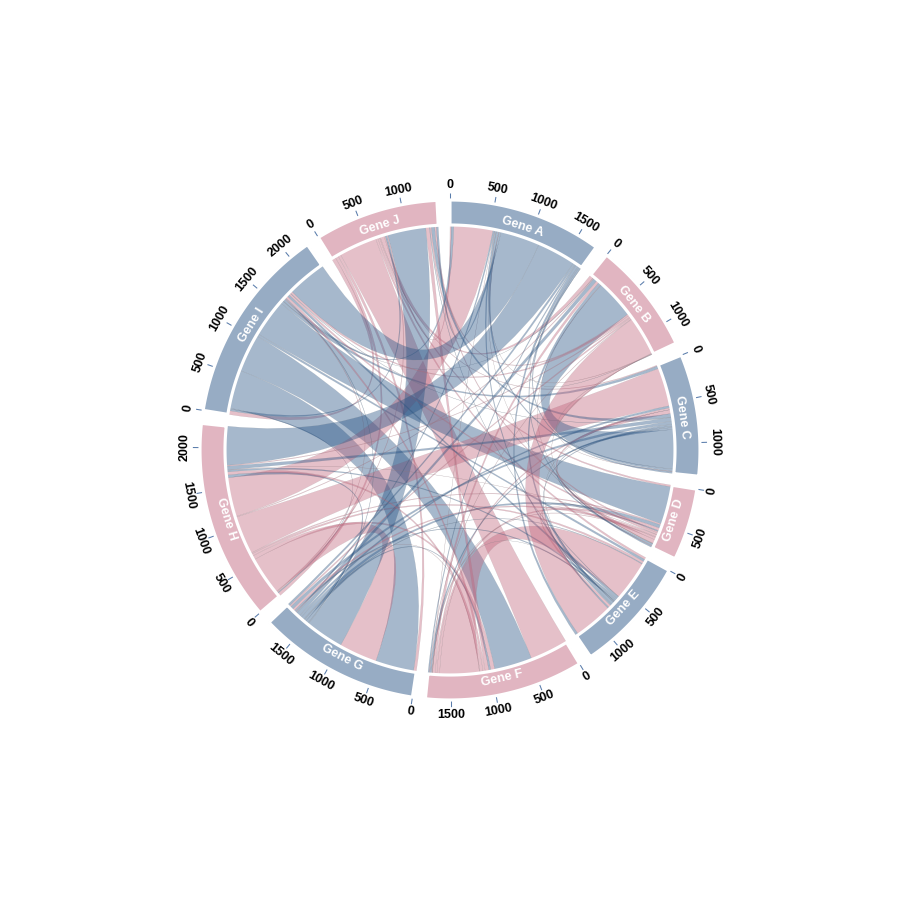

In [5]:
import numpy as np
import pandas as pd

def generate_random_matrix(size, min_value, max_value, large_value_prob=0.1):
    """生成一个随机矩阵"""
    matrix = np.zeros((size, size))  # 初始化矩阵
    for i in range(size):
        for j in range(size):
            if i != j:  # 非对角线元素
                # 根据概率决定生成大值或小值
                if np.random.rand() < large_value_prob:
                    matrix[i][j] = np.random.uniform(max_value * 0.95, max_value)
                else:
                    matrix[i][j] = np.random.uniform(min_value, max_value * 0.1)
    return matrix.tolist()


# 创建基因相互作用强度矩阵数据（改为英文标识）
labels = ["Gene A", "Gene B", "Gene C", "Gene D", "Gene E",
          "Gene F", "Gene G", "Gene H", "Gene I", "Gene J"]

# 创建自定义颜色映射
color_map = ["#214e81", "#c0627a"] * 5
cmap = {}
link_cmap = {}

for i in range(len(labels)):
    cmap[labels[i]] = color_map[i] + "77"
# 设置矩阵大小和数值范围
size = 10  # 矩阵大小 (10 x 10)
min_value = 1  # 最小值
max_value = 500  # 最大值
# 生成随机矩阵
np.random.seed(2)
interaction_data = generate_random_matrix(size, min_value, max_value, 0.2)
# 创建数据框
interaction_df = pd.DataFrame(interaction_data,
                              index=labels, columns=labels)
# 从矩阵初始化 Circos 图
circos = Circos.initialize_from_matrix(
    interaction_df,
    space=3,  # 各区段之间的间隔
    r_lim=(63, 70),  # 环形图的半径范围
    cmap=cmap,  # 颜色映射方案
    ticks_interval=500,  # 刻度间隔
    label_kws=dict(r=64, size=6, color="#ffffff",
                   fontweight="bold"),  # 标签参数
    ticks_kws=dict(
        line_kws=dict(ec="#597cab"),
        text_kws=dict(weight="bold"), label_size=6
    ),
    link_kws=dict(alpha=0.4),
)
# 设置区段边线
for i, sector in enumerate(circos.sectors):
    sector.tracks[0].axis(ec="#ffffff", lw=1.5)
fig = circos.plotfig(figsize=(8, 5), dpi=150)
# 标题改为英文
# fig.suptitle("Chord Diagram of Gene Expression", x=0.22, y=0.57, fontsize=22)
# fig.text(x=0.065, y=0.47, s="Chord Diagram of Gene Expression", fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(left=0.33, right=1, top=1, bottom=0)
plt.show()